In [26]:
from pathlib import Path
from zipfile import ZipFile
import urllib.request

import pandas as pd

# Cache the official UCI archive in the project data folder
workspace = Path.cwd()
data_dir = workspace / "data"
if not data_dir.is_dir() and (workspace.parent / "data").is_dir():
    data_dir = workspace.parent / "data"
data_dir.mkdir(parents=True, exist_ok=True)
archive_path = data_dir / "gas_turbine_co_and_nox_emission.zip"

if not archive_path.exists():
    download_url = "https://archive.ics.uci.edu/static/public/551/gas+turbine+co+and+nox+emission+data+set.zip"
    urllib.request.urlretrieve(download_url, archive_path)

# Combine the yearly CSV files in chronological order
with ZipFile(archive_path) as archive:
    csv_names = sorted(name for name in archive.namelist() if name.lower().endswith(".csv"))
    yearly_data = []
    for csv_name in csv_names:
        frame = pd.read_csv(archive.open(csv_name))
        if "year" not in frame.columns:
            frame.insert(0, "year", int(Path(csv_name).stem[-4:]))
        yearly_data.append(frame)
    X = pd.concat(yearly_data, ignore_index=True)

y = X[['CO']].copy()

# View the first 5 rows to confirm it loaded
X.head()

,year,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX
0,2011,4.5878,1018.7,83.675,3.5758,23.979,1086.2,549.83,134.67,11.898,0.32663,81.952
1,2011,4.2932,1018.3,84.235,3.5709,23.951,1086.1,550.05,134.67,11.892,0.44784,82.377
2,2011,3.9045,1018.4,84.858,3.5828,23.990,1086.5,550.19,135.10,12.042,0.45144,83.776
3,2011,3.7436,1018.3,85.434,3.5808,23.911,1086.5,550.17,135.03,11.990,0.23107,82.505
4,2011,3.7516,1017.8,85.182,3.5781,23.917,1085.9,550.00,134.67,11.910,0.26747,82.028


year: The year the data was recorded.

AT : (Ambient Temperature).

AP : (Ambient Pressure).

AH : (Ambient Humidity).

AFDP (Air Filter Difference Pressure): The pressure drop across the intake air filter, which indicates how hard the compressor has to pull to get air.

GTEP (Gas Turbine Exhaust Pressure): The pressure of the hot gas exiting the turbine.

TIT (Turbine Inlet Temperature): The extremely high temperature of the gas immediately before it hits the turbine blades.

TAT (Turbine After Temperature): The temperature of the gas after it has passed through the turbine blades.

TEY (Turbine Energy Yield): The actual electrical power output generated by the turbine.

CDP (Compressor Discharge Pressure): The pressure of the air immediately after it has been squeezed by the compressor but before fuel is added.

CO : One of the difficult-to-measure target emissions your soft sensor will learn to predict.

NOX : The other difficult-to-measure target emission your soft sensor will learn to predict.


1. Inspect the Physical Sensor Features
First, take a quick look at the statistical distribution of the secondary sensors to understand their normal operating ranges.

In [27]:
# View basic statistics of the sensor readings
X.describe()

,year,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX
count,36733.000000,36733.000000,36733.000000,36733.000000,36733.000000,36733.000000,36733.000000,36733.000000,36733.000000,36733.000000,36733.000000,36733.000000
mean,2012.985735,17.712726,1013.070165,77.867015,3.925518,25.563801,1081.428084,546.158517,133.506404,12.060525,2.372468,65.293067
std,1.418965,7.447451,6.463346,14.461355,0.773936,4.195957,17.536373,6.842360,15.618634,1.088795,2.262672,11.678357
min,2011.000000,-6.234800,985.850000,24.085000,2.087400,17.698000,1000.800000,511.040000,100.020000,9.851800,0.000388,25.905000
25%,2012.000000,11.781000,1008.800000,68.188000,3.355600,23.129000,1071.800000,544.720000,124.450000,11.435000,1.182400,57.162000
50%,2013.000000,17.801000,1012.600000,80.470000,3.937700,25.104000,1085.900000,549.880000,133.730000,11.965000,1.713500,63.849000
75%,2014.000000,23.665000,1017.000000,89.376000,4.376900,29.061000,1097.000000,550.040000,144.080000,12.855000,2.842900,71.548000
max,2015.000000,37.103000,1036.600000,100.200000,7.610600,40.716000,1100.900000,550.610000,179.500000,15.159000,44.103000,119.910000


2. Simulate Sensor Degradation (Drift)
Physical sensors in extreme gas turbine environments inevitably degrade or drift. To practice detecting this, I have artificially injected noise into the Ambient Temperature (AT) sensor to simulate it failing toward the end of the dataset.

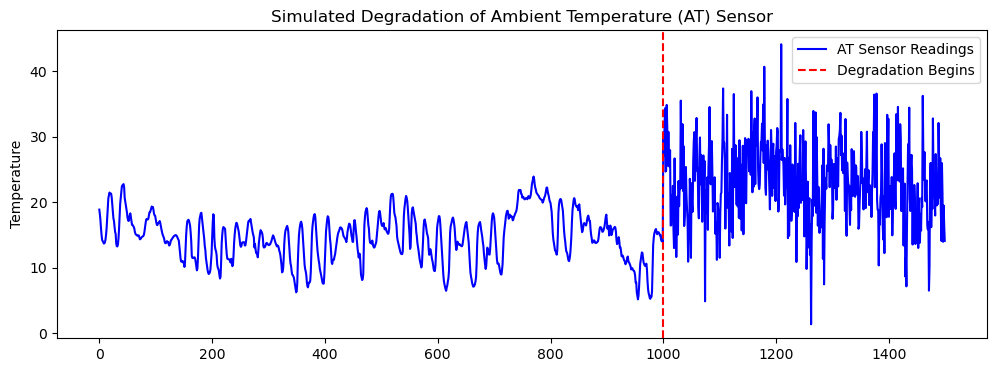

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Create a copy of the features so I don't permanently ruin the original data
X_noisy = X.copy()

# Inject severe noise into the last 500 hours of the 'AT' (Ambient Temperature) sensor
# This mimics a physical sensor drifting off calibration
np.random.seed(42)
noise = np.random.normal(loc=15, scale=5, size=500)
X_noisy.loc[X_noisy.index[-500:], 'AT'] += noise

# Plot the last 1500 hours to visually see the sensor degrading
plt.figure(figsize=(12, 4))
plt.plot(X_noisy['AT'].values[-1500:], color='blue', label='AT Sensor Readings')
plt.axvline(x=1000, color='red', linestyle='--', label='Degradation Begins')
plt.title('Simulated Degradation of Ambient Temperature (AT) Sensor')
plt.ylabel('Temperature')
plt.legend()
plt.show()

3. Build an Anomaly Detection Model
A robust machine learning algorithm must recognize when its input data is compromised. I am gonna use an Isolation Forest, a standard unsupervised learning algorithm, to flag these abnormal readings.

In [ ]:
from sklearn.ensemble import IsolationForest

# Initialize the Isolation Forest
# contamination=0.02 means I estimate roughly 2% of our fleet data might be faulty
iso_forest = IsolationForest(contamination=0.02, random_state=42)

# Fit the model and predict anomalies on the noisy AT sensor data
# It returns 1 for normal data, and -1 for anomalies
X_noisy['Anomaly'] = iso_forest.fit_predict(X_noisy[['AT']])

# Count how many data points were flagged as anomalies
print("Anomaly Detection Results:")
print(X_noisy['Anomaly'].value_counts())

Anomaly Detection Results:
Anomaly
 1    36006
-1      727
Name: count, dtype: int64


4. Data reduction

4. 1. Filter out the Anomalies

In [30]:
# Keep only the healthy data (where Anomaly == 1)
X_clean = X_noisy[X_noisy['Anomaly'] == 1].drop(columns=['Anomaly'])
print(f"Remaining clean records: {len(X_clean)}")

Remaining clean records: 36006


4.2. Check for Multicollinearity

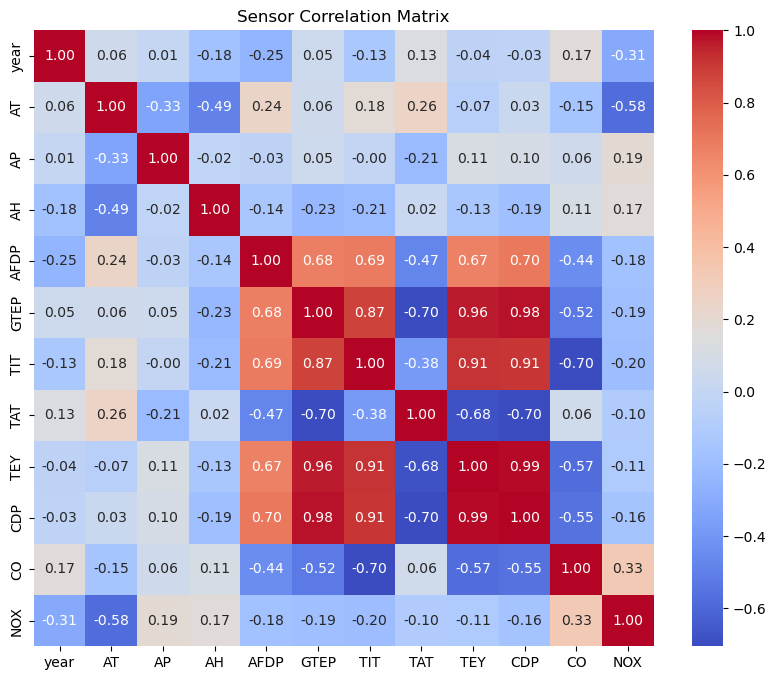

In [31]:
import seaborn as sns

# Plot a correlation heatmap of the clean data
plt.figure(figsize=(10, 8))
sns.heatmap(X_clean.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Sensor Correlation Matrix')
plt.show()

4.3. Compress the Data (PCA)

In [32]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize the data (PCA requires all sensors to be on the same scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

# Apply PCA to keep enough components to explain 95% of the variance
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print(f"Original number of sensors: {X_clean.shape[1]}")
print(f"Reduced number of principal components: {X_pca.shape[1]}")

Original number of sensors: 12
Reduced number of principal components: 7


In [33]:
print(type(y))
print(y)

<class 'pandas.core.frame.DataFrame'>
             CO
0       0.32663
1       0.44784
2       0.45144
3       0.23107
4       0.26747
...         ...
36728  10.99300
36729  11.14400
36730  11.41400
36731   3.31340
36732  11.98100

[36733 rows x 1 columns]


5. Soft Sensor Development

5. 1. Isolate the Target Variable

In [ ]:
from sklearn.model_selection import train_test_split

# Only need to grab CO readings for healthy sensor data
y_clean = y.loc[X_clean.index, 'CO']

# Split the data into 80% for training the soft sensor, and 20% for testing its accuracy
X_train, X_test, y_train, y_test = train_test_split(X_pca, y_clean, test_size=0.2, random_state=42)

5. 2. Train the Soft Sensor

In [35]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the model (using 100 decision trees)
rf_soft_sensor = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model on the 80% training data
print("Training soft sensor... (this may take 10-20 seconds)")
rf_soft_sensor.fit(X_train, y_train)

Training soft sensor... (this may take 10-20 seconds)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


5. 3. Evaluate the Soft Sensor Accuracy

Soft Sensor R-squared (Accuracy): 0.9674
Soft Sensor Mean Squared Error: 0.1934


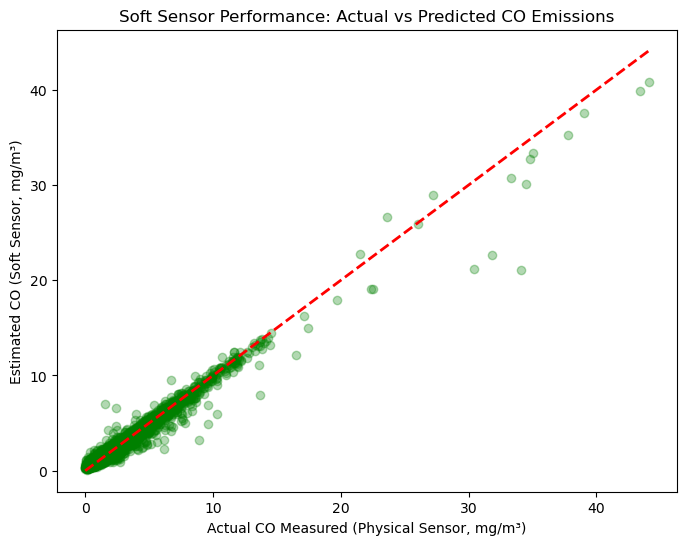

In [37]:
# Generate CO estimates based purely on the 7 PCA components
y_pred = rf_soft_sensor.predict(X_test)

# Calculate error metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Soft Sensor R-squared (Accuracy): {r2:.4f}")
print(f"Soft Sensor Mean Squared Error: {mse:.4f}")

# Visualize the accuracy (Predicted vs Actual)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Soft Sensor Performance: Actual vs Predicted CO Emissions')
plt.xlabel('Actual CO Measured (Physical Sensor, mg/m³)')
plt.ylabel('Estimated CO (Soft Sensor, mg/m³)')
plt.show()